**COMPLEX TERRAIN METEOROLOGY LAB - USAGE OF PROMETEO FUNCTIONS IN A CUSTOM SCRIPT**

In [1]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import core as core
import pre_processing as pre_processing
import frame as frame

The logger is the way the computer communicate to the user (it's not essential, but some functions uses it)

In [2]:
# logger configuration
import logging

logger = logging.getLogger("notebook_logger")
logger.setLevel(logging.INFO)

handler = logging.StreamHandler()
handler.setLevel(logging.INFO)

if not logger.handlers:
    logger.addHandler(handler)

logger.propagate = False

logger.info("Logger initialized.")

Logger initialized.


In [3]:
# how to call the documentation
pre_processing.despiking_VM97??

Signature:
pre_processing.despiking_VM97(
    array_to_despike: numpy.ndarray,
    c: float,
    window_length: int,
    max_consecutive_spikes: int,
    max_iterations: int,
    logger: Optional[logging.Logger] = None,
) -> numpy.ndarray
Source:   
def despiking_VM97(array_to_despike : np.ndarray,
                   c : float,
                   window_length : int,
                   max_consecutive_spikes : int,
                   max_iterations : int,
                   logger : Optional[logging.Logger] = None
                   ) -> np.ndarray:
    """
    Applies the despiking algorithm based on Vickers and Mahrt (1997) to remove spikes from a time series.

    This method identifies and replaces spikes in the input array by comparing values against a running
    mean and standard deviation computed over a moving window. Points lying beyond a threshold defined
    by `c` times the local standard deviation from the local mean are considered spikes. Spikes are 
    replaced using i

In [4]:
# data import
path_input = '/home/alessandro/projects/MATERHORN_data/ES3_10_02_2012_cut/ES3_sonic_10_2012-10-02.csv'
ES3_10m_raw= pd.read_csv(path_input, sep=",", header=0)

How to visualize rapidly some info about the dataframe

In [5]:
ES3_10m_raw

,Time,u,v,w,T_s
0,2012-10-02 00:30:00.000,0.220,1.785,0.011,296.50000
1,2012-10-02 00:30:00.050,0.220,1.787,0.069,296.50000
2,2012-10-02 00:30:00.100,0.123,1.787,-0.035,296.60001
3,2012-10-02 00:30:00.150,0.160,1.773,-0.074,296.60001
4,2012-10-02 00:30:00.200,0.220,1.776,-0.077,296.60001
...,...,...,...,...,...
287696,2012-10-02 04:29:59.800,-3.136,-0.350,-0.136,295.50000
287697,2012-10-02 04:29:59.850,-3.134,-0.350,-0.136,295.50000
287698,2012-10-02 04:29:59.900,-3.160,-0.325,-0.185,295.39999
287699,2012-10-02 04:29:59.950,-3.086,-0.300,-0.136,295.50000


In [6]:
ES3_10m_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 287701 entries, 0 to 287700
Data columns (total 5 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    287701 non-null  object 
 1   u       287679 non-null  float64
 2   v       287679 non-null  float64
 3   w       287679 non-null  float64
 4   T_s     287679 non-null  float64
dtypes: float64(4), object(1)
memory usage: 11.0+ MB


In [7]:
ES3_10m_raw.dtypes

Time     object
u       float64
v       float64
w       float64
T_s     float64
dtype: object

Set the timestamp column as index

In [8]:
ES3_10m_raw["Time"] = pd.to_datetime(ES3_10m_raw["Time"])
ES3_10m_raw.set_index("Time", inplace=True)

In [9]:
ES3_10m_raw

,u,v,w,T_s
Time,,,,
2012-10-02 00:30:00.000,0.220,1.785,0.011,296.50000
2012-10-02 00:30:00.050,0.220,1.787,0.069,296.50000
2012-10-02 00:30:00.100,0.123,1.787,-0.035,296.60001
2012-10-02 00:30:00.150,0.160,1.773,-0.074,296.60001
2012-10-02 00:30:00.200,0.220,1.776,-0.077,296.60001
...,...,...,...,...
2012-10-02 04:29:59.800,-3.136,-0.350,-0.136,295.50000
2012-10-02 04:29:59.850,-3.134,-0.350,-0.136,295.50000
2012-10-02 04:29:59.900,-3.160,-0.325,-0.185,295.39999


In [10]:
# fill missing timestamps
ES3_10m_complete = pre_processing.fill_missing_timestamps(ES3_10m_raw, freq=20)
time = ES3_10m_complete.index

In [11]:
print(f"Points in the rawdata: {len(ES3_10m_raw)}")
print(f"Points after filling timestamps procedure: {len(ES3_10m_complete)}")

Points in the rawdata: 287701
Points after filling timestamps procedure: 288001


In [12]:
# remove values beyond threshold
horizontal_threshold = 30
vertical_threshold = 4
temperature_threshold = 310

u_clean, count_beyond_u = pre_processing.remove_beyond_threshold(ES3_10m_complete["u"].to_numpy(), 
                                                               horizontal_threshold)
v_clean, count_beyond_v = pre_processing.remove_beyond_threshold(ES3_10m_complete["v"].to_numpy(), 
                                                               horizontal_threshold)
w_clean, count_beyond_w = pre_processing.remove_beyond_threshold(ES3_10m_complete["w"].to_numpy(), 
                                                               vertical_threshold)
T_s_clean, count_beyond_T = pre_processing.remove_beyond_threshold(ES3_10m_complete["T_s"].to_numpy(), 
                                                               temperature_threshold)

print(f"Removed values beyond horizontal threshold in u: {count_beyond_u}")
print(f"Removed values beyond horizontal threshold in v: {count_beyond_v}")
print(f"Removed values beyond vertical threshold in w: {count_beyond_w}")
print(f"Removed values beyond temperature threshold in T: {count_beyond_T}")


Removed values beyond horizontal threshold in u: 10
Removed values beyond horizontal threshold in v: 10
Removed values beyond vertical threshold in w: 10
Removed values beyond temperature threshold in T: 10


In [13]:
ES3_10m_clean = pd.DataFrame({
    "u": u_clean,
    "v": v_clean,
    "w": w_clean,
    "T_s": T_s_clean
}, index=time)

In [14]:
ES3_10m_clean

,u,v,w,T_s
2012-10-02 00:30:00.000,0.220,1.785,0.011,296.50000
2012-10-02 00:30:00.050,0.220,1.787,0.069,296.50000
2012-10-02 00:30:00.100,0.123,1.787,-0.035,296.60001
2012-10-02 00:30:00.150,0.160,1.773,-0.074,296.60001
2012-10-02 00:30:00.200,0.220,1.776,-0.077,296.60001
...,...,...,...,...
2012-10-02 04:29:59.800,-3.136,-0.350,-0.136,295.50000
2012-10-02 04:29:59.850,-3.134,-0.350,-0.136,295.50000
2012-10-02 04:29:59.900,-3.160,-0.325,-0.185,295.39999
2012-10-02 04:29:59.950,-3.086,-0.300,-0.136,295.50000


In [15]:
# cleaning environment

del count_beyond_u, count_beyond_v, count_beyond_w, count_beyond_T
del ES3_10m_complete
del ES3_10m_raw

In [16]:
# defining despiking parameters
window_length = core.min_to_points(minutes = 5, sampling_freq = 20)
c_H = 3.5
c_V = 5
c_T = 3.5
max_consecutive_spikes = 3
max_iterations = 4

In [17]:
# despiking
u_desp = pre_processing.despiking_VM97(ES3_10m_clean["u"].to_numpy(),
                   c = c_H,
                   window_length = window_length,
                   max_consecutive_spikes = max_consecutive_spikes,
                   max_iterations = max_iterations,
                   logger = logger)



                Iteration: 0, identified and removed spikes: 15
            

                Iteration: 1, identified and removed spikes: 0
            


In [18]:
v_desp = pre_processing.despiking_VM97(ES3_10m_clean["v"].to_numpy(),
                   c = c_H,
                   window_length = window_length,
                   max_consecutive_spikes = max_consecutive_spikes,
                   max_iterations = max_iterations,
                   logger = logger)


                Iteration: 0, identified and removed spikes: 54
            

                Iteration: 1, identified and removed spikes: 11
            

                Iteration: 2, identified and removed spikes: 8
            

                Iteration: 3, identified and removed spikes: 9
            


In [19]:
w_desp = pre_processing.despiking_VM97(ES3_10m_clean["w"].to_numpy(),
                   c = c_V,
                   window_length = window_length,
                   max_consecutive_spikes = max_consecutive_spikes,
                   max_iterations = max_iterations,
                   logger = logger)


                Iteration: 0, identified and removed spikes: 9
            

                Iteration: 1, identified and removed spikes: 0
            


In [20]:
T_s_desp = pre_processing.despiking_VM97(ES3_10m_clean["T_s"].to_numpy(),
                   c = c_T,
                   window_length = window_length,
                   max_consecutive_spikes = max_consecutive_spikes,
                   max_iterations = max_iterations,
                   logger = logger)


                Iteration: 0, identified and removed spikes: 104
            

                Iteration: 1, identified and removed spikes: 12
            

                Iteration: 2, identified and removed spikes: 13
            

                Iteration: 3, identified and removed spikes: 3
            


In [21]:
ES3_10m_desp = pd.DataFrame({
    "u": u_desp,
    "v": v_desp,
    "w": w_desp,
    "T_s": T_s_desp
}, index=time)
ES3_10m_desp

,u,v,w,T_s
2012-10-02 00:30:00.000,0.220,1.785,0.011,296.50000
2012-10-02 00:30:00.050,0.220,1.787,0.069,296.50000
2012-10-02 00:30:00.100,0.123,1.787,-0.035,296.60001
2012-10-02 00:30:00.150,0.160,1.773,-0.074,296.60001
2012-10-02 00:30:00.200,0.220,1.776,-0.077,296.60001
...,...,...,...,...
2012-10-02 04:29:59.800,-3.136,-0.350,-0.136,295.50000
2012-10-02 04:29:59.850,-3.134,-0.350,-0.136,295.50000
2012-10-02 04:29:59.900,-3.160,-0.325,-0.185,295.39999
2012-10-02 04:29:59.950,-3.086,-0.300,-0.136,295.50000


In [22]:
# counting changed values for u
nan_mask_final_u = np.isnan(ES3_10m_clean['u']) & np.isnan(ES3_10m_desp['u'])
diff_mask_final_u = np.not_equal(ES3_10m_clean['u'], ES3_10m_desp['u'])
modified_mask_final_u = diff_mask_final_u & ~nan_mask_final_u
print(f"Changed values for u in the Despiking VM97 procedure: {np.sum(modified_mask_final_u)}")

Changed values for u in the Despiking VM97 procedure: 23


In [23]:
# counting changed values for v
nan_mask_final_v = np.isnan(ES3_10m_clean['v']) & np.isnan(ES3_10m_desp['v'])
diff_mask_final_v = np.not_equal(ES3_10m_clean['v'], ES3_10m_desp['v'])
modified_mask_final_v = diff_mask_final_v & ~nan_mask_final_v
print(f"Changed values for v in the Despiking VM97 procedure: {np.sum(modified_mask_final_v)}")

Changed values for v in the Despiking VM97 procedure: 138


In [24]:
# counting changed values for w
nan_mask_final_w = np.isnan(ES3_10m_clean['w']) & np.isnan(ES3_10m_desp['w'])
diff_mask_final_w = np.not_equal(ES3_10m_clean['w'], ES3_10m_desp['w'])
modified_mask_final_w = diff_mask_final_w & ~nan_mask_final_w
print(f"Changed values for w in the Despiking VM97 procedure: {np.sum(modified_mask_final_w)}")

Changed values for w in the Despiking VM97 procedure: 10


In [25]:
# counting changed values for T_s
nan_mask_final_T_s = np.isnan(ES3_10m_clean['T_s']) & np.isnan(ES3_10m_desp['T_s'])
diff_mask_final_T_s = np.not_equal(ES3_10m_clean['T_s'], ES3_10m_desp['T_s'])
modified_mask_final_T_s = diff_mask_final_T_s & ~nan_mask_final_T_s
print(f"Changed values for T_s in the Despiking VM97 procedure: {np.sum(modified_mask_final_T_s)}")

Changed values for T_s in the Despiking VM97 procedure: 213


In [26]:
# cleaning environment
del ES3_10m_clean

In [27]:
# interp missing values
u_interp, count_interp_u = pre_processing.interp_nan(ES3_10m_desp['u'].to_numpy())
print(f"Interpolated values for u: {count_interp_u}")
v_interp, count_interp_v = pre_processing.interp_nan(ES3_10m_desp['v'].to_numpy())
print(f"Interpolated values for v: {count_interp_v}")
w_interp, count_interp_w = pre_processing.interp_nan(ES3_10m_desp['w'].to_numpy())
print(f"Interpolated values: {count_interp_w}")
T_s_interp, count_interp_T_s = pre_processing.interp_nan(ES3_10m_desp['T_s'].to_numpy())
print(f"Interpolated values for T_s: {count_interp_T_s}")

Interpolated values for u: 332
Interpolated values for v: 332
Interpolated values: 332
Interpolated values for T_s: 332


In [28]:
ES3_10m_preprocessed = pd.DataFrame({
    "u": u_interp,
    "v": v_interp,
    "w": w_interp,
    "T_s": T_s_interp
}, index=time)


In [29]:
# cleaning environment
del u_desp, v_desp, w_desp, T_s_desp
del ES3_10m_desp

Frame rotation

In [30]:
# frame rotation in streamline frame
sampling_freq = 20  # Hz
window_length_averaging = 5   # minutes
window_avg_points = core.min_to_points(sampling_freq, window_length_averaging)

azimuth = 0  # degrees
model = 'RM_YOUNG_81000'
wind_dir_threshold = 0.01  # m/s

wind = np.array([ES3_10m_preprocessed['u'].to_numpy(),
                 ES3_10m_preprocessed['v'].to_numpy(),
                ES3_10m_preprocessed['w'].to_numpy()])
wind_averaged = np.zeros_like(wind)

    # if reference_frame == "LEC":
    #     # Rotation to Local Earth Coordinate (LEC) system
    #     wind_rotated = frame.rotation_to_LEC_reference(wind, azimuth, model)
    #     for i in range(3):
    #         wind_averaged[i, :], _ = core.running_stats(wind_rotated[i, :], window_avg_points)
    #     wind_direction = frame.wind_dir_LEC_reference(wind_averaged[0], wind_averaged[1], wind_dir_threshold)

# Rotation to streamline reference frame
for i, comp in enumerate(['u', 'v', 'w']):
    # mean wind computation
    wind_averaged[i, :], _ = core.running_stats(ES3_10m_preprocessed[comp].to_numpy(), window_avg_points)

wind_rotated = frame.rotation_to_streamline_reference(wind, wind_averaged)

Wind direction computation

In [31]:
# wind direction computation

wind_direction = frame.wind_dir_modeldependent_reference(wind_averaged[0], wind_averaged[1], azimuth, model, wind_dir_threshold)
del wind_averaged  # Clean up

In [32]:
ES3_10_final = pd.DataFrame({
    "u": wind_rotated[0, :],
    "v": wind_rotated[1, :],
    "w": wind_rotated[2, :],
    "T_s": ES3_10m_preprocessed['T_s'].to_numpy(),
    "wind_dir": wind_direction
}, index=time)

In [33]:
# .csv export
path_output = '/home/alessandro/projects/prova/ES3_10_final.csv'
ES3_10_final.to_csv(path_output, sep=",", header=True, index=True)
print(f"Data exported to: {path_output}")

Data exported to: /home/alessandro/projects/prova/ES3_10_final.csv


Basic usage of pandas to perform resampling and averaging

In [34]:
# remove a column
df = ES3_10_final.copy()
df = df.drop(["wind_dir"], axis=1)
df


,u,v,w,T_s
2012-10-02 00:30:00.000,1.763757,-0.351859,-0.010146,296.50000
2012-10-02 00:30:00.050,1.766420,-0.352127,0.047911,296.50000
2012-10-02 00:30:00.100,1.772369,-0.255508,-0.056080,296.60001
2012-10-02 00:30:00.150,1.755181,-0.291473,-0.094811,296.60001
2012-10-02 00:30:00.200,1.753655,-0.351637,-0.097726,296.60001
...,...,...,...,...
2012-10-02 04:29:59.800,3.158293,0.008341,0.024620,295.50000
2012-10-02 04:29:59.850,3.156308,0.008594,0.024494,295.50000
2012-10-02 04:29:59.900,3.181909,-0.019049,-0.023284,295.39999
2012-10-02 04:29:59.950,3.103246,-0.035854,0.021752,295.50000


In [35]:
df_resampled = df.resample("5min").mean()  # block average
df_resampled

,u,v,w,T_s
2012-10-02 00:30:00,1.294062,0.166621,0.003968,296.175770
2012-10-02 00:35:00,2.191539,-0.027824,-0.000273,296.231167
2012-10-02 00:40:00,1.392094,0.078584,0.009443,296.401733
2012-10-02 00:45:00,2.759123,-0.145360,-0.014432,296.564784
2012-10-02 00:50:00,1.458521,0.047662,0.009869,295.902302
2012-10-02 00:55:00,2.071363,0.093252,-0.000337,295.939859
2012-10-02 01:00:00,2.089852,-0.011926,-0.006047,295.636951
2012-10-02 01:05:00,1.910181,0.017032,-0.001016,295.744122
2012-10-02 01:10:00,1.503580,0.006414,0.004123,295.951697
2012-10-02 01:15:00,1.729167,-0.095619,0.002045,296.154341


In [36]:
# computing wind direction from block-averaged u and v (from the original reference)
wind_direction = frame.wind_dir_modeldependent_reference(ES3_10m_preprocessed['u'].resample("5min").mean(),
                                                         ES3_10m_preprocessed['v'].resample("5min").mean(), 
                                                         azimuth, model, wind_dir_threshold)


In [37]:
# attach the new column to the previous dataframe
df_resampled["wind_dir"] = wind_direction
df_resampled

,u,v,w,T_s,wind_dir
2012-10-02 00:30:00,1.294062,0.166621,0.003968,296.175770,344.088613
2012-10-02 00:35:00,2.191539,-0.027824,-0.000273,296.231167,11.024672
2012-10-02 00:40:00,1.392094,0.078584,0.009443,296.401733,4.286189
2012-10-02 00:45:00,2.759123,-0.145360,-0.014432,296.564784,9.755650
2012-10-02 00:50:00,1.458521,0.047662,0.009869,295.902302,343.332022
2012-10-02 00:55:00,2.071363,0.093252,-0.000337,295.939859,349.712870
2012-10-02 01:00:00,2.089852,-0.011926,-0.006047,295.636951,353.523509
2012-10-02 01:05:00,1.910181,0.017032,-0.001016,295.744122,329.762126
2012-10-02 01:10:00,1.503580,0.006414,0.004123,295.951697,335.073852
2012-10-02 01:15:00,1.729167,-0.095619,0.002045,296.154341,338.106688


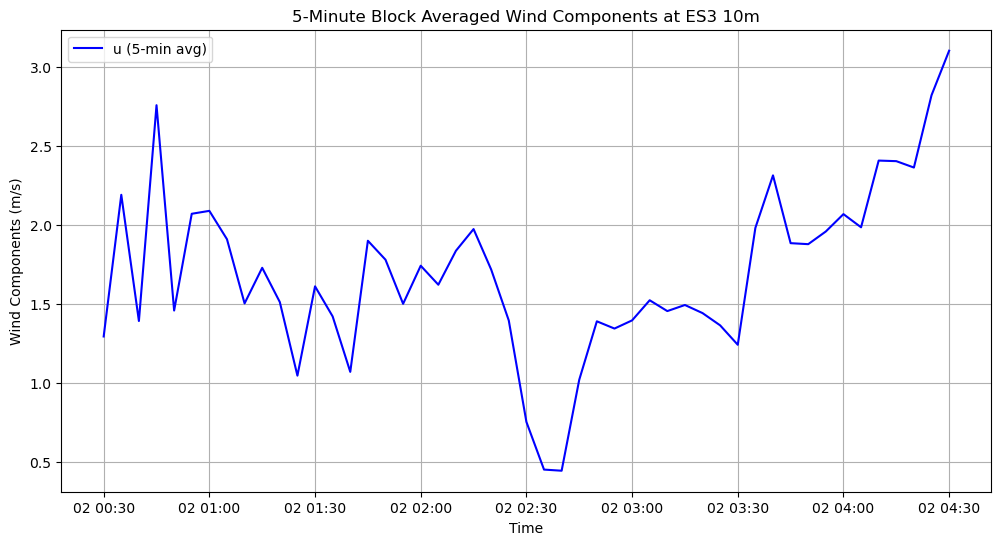

In [38]:
# simple plot
plt.figure(figsize=(12, 6))
plt.plot(df_resampled.index, df_resampled['u'], label='u (5-min avg)', color='blue')
plt.xlabel('Time')
plt.ylabel('Wind Components (m/s)')
plt.title('5-Minute Block Averaged Wind Components at ES3 10m')
plt.legend()
plt.grid()
plt.show()

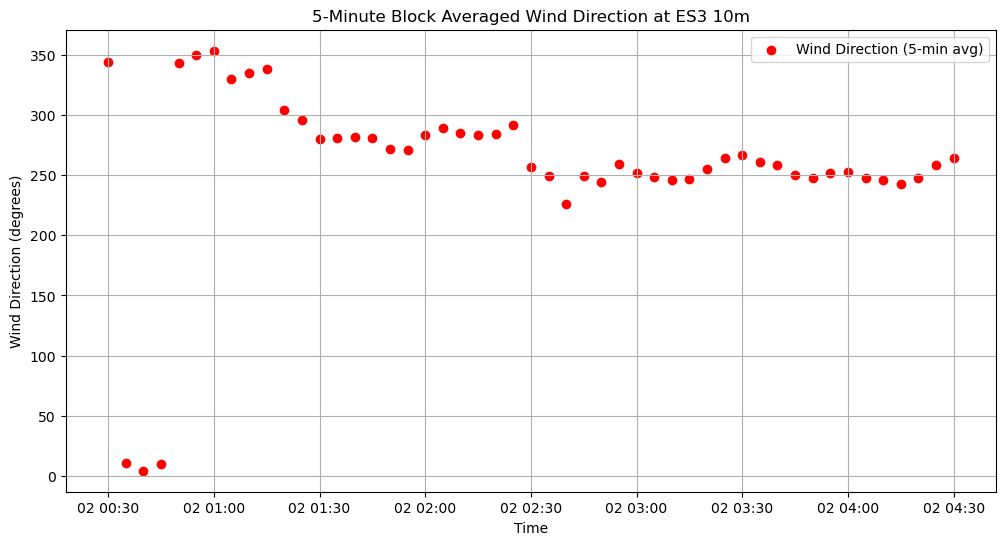

In [39]:
# visualizing wind direction
plt.figure(figsize=(12, 6))
plt.scatter(df_resampled.index, df_resampled['wind_dir'], label='Wind Direction (5-min avg)', color='red')
plt.xlabel('Time')
plt.ylabel('Wind Direction (degrees)')
plt.title('5-Minute Block Averaged Wind Direction at ES3 10m')
plt.legend()
plt.grid()
plt.show()

In [40]:
# cutting the dataframe to a specific time window
start_cut = pd.to_datetime("2012-10-02 02:00:00")
end_cut = pd.to_datetime("2012-10-02 04:00:00")
df_cut = df_resampled.loc[start_cut:end_cut]
df_cut

,u,v,w,T_s,wind_dir
2012-10-02 02:00:00,1.742306,0.002928,-0.008559,296.011800,283.071725
2012-10-02 02:05:00,1.621933,-0.051315,-0.002173,295.993418,289.502317
2012-10-02 02:10:00,1.837143,0.023364,0.010443,295.915676,284.909390
2012-10-02 02:15:00,1.974391,0.025146,-0.007045,295.836283,283.170450
2012-10-02 02:20:00,1.718179,0.006764,0.000716,295.730083,284.423939
2012-10-02 02:25:00,1.395253,-0.057215,0.002135,295.724592,291.712441
2012-10-02 02:30:00,0.753074,0.062264,-0.001075,295.745381,256.489877
2012-10-02 02:35:00,0.450926,-0.021426,-0.000851,295.606567,249.698297
2012-10-02 02:40:00,0.443715,0.028208,-0.000202,295.654258,225.931432
2012-10-02 02:45:00,1.019968,-0.031267,0.000208,295.229836,249.267551
